In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

def get_dataloaders(data_dir, batch_size=32, img_size=64, shuffle=True):
    # standard preprocessing for VAEs
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])

    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
    # Filter for only Cats (label 0) and Dogs (label 1) 
    # AFHQ structure is usually: 0:cat, 1:dog, 2:wild
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle)
    return loader, full_dataset.classes

def visualize_transformation(model, dataloader, device):
    model.eval()
    images, labels = next(iter(dataloader))
    
    # Pick only the cats from the batch
    cat_indices = (labels == 0).nonzero(as_tuple=True)[0]
    if len(cat_indices) == 0: return
    
    cats = images[cat_indices[:4]].to(device)
    
    with torch.no_grad():
        # 1. Encode Cats
        mu, _ = model.encode(cats, torch.zeros(len(cats), dtype=torch.long).to(device))
        
        # 2. Decode as Dogs (Label 1)
        dog_labels = torch.ones(len(cats), dtype=torch.long).to(device)
        transformed_dogs = model.decode(mu, dog_labels)

    # Plotting
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(len(cats)):
        # Show Original Cat
        orig = cats[i].cpu() * 0.5 + 0.5
        axes[0, i].imshow(np.transpose(orig, (1, 2, 0)))
        axes[0, i].set_title("Original Cat")
        axes[0, i].axis('off')
        
        # Show Transformed Dog
        trans = transformed_dogs[i].cpu() * 0.5 + 0.5
        axes[1, i].imshow(np.transpose(trans, (1, 2, 0)))
        axes[1, i].set_title("Transformed Dog")
        axes[1, i].axis('off')
    plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    images = images * 0.5 + 0.5 
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=2, img_channels=3):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Label embedding for conditioning
        self.label_emb = nn.Embedding(num_classes, 64)
        
        # Encoder: Conv layers to compress image
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels + 1, 32, kernel_size=4, stride=2, padding=1), # Add 1 for label channel
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        
        # Latent space headers
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)
        
        # Decoder: Deconv layers to reconstruct image
        self.decoder_input = nn.Linear(latent_dim + 64, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh() # Output scaled -1 to 1
        )

    def encode(self, x, y):
        # Inject label by creating a channel of the same spatial size
        y_encoded = y.view(-1, 1, 1, 1).expand(-1, 1, x.size(2), x.size(3))
        x_cond = torch.cat([x, y_encoded], dim=1)
        
        h = self.encoder(x_cond)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        z_cond = torch.cat([z, y_emb], dim=1)
        
        h = self.decoder_input(z_cond)
        h = h.view(-1, 128, 8, 8)
        return self.decoder(h)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

# --- Loss Function ---
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE or BCE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence: forces latent space to be normal distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss

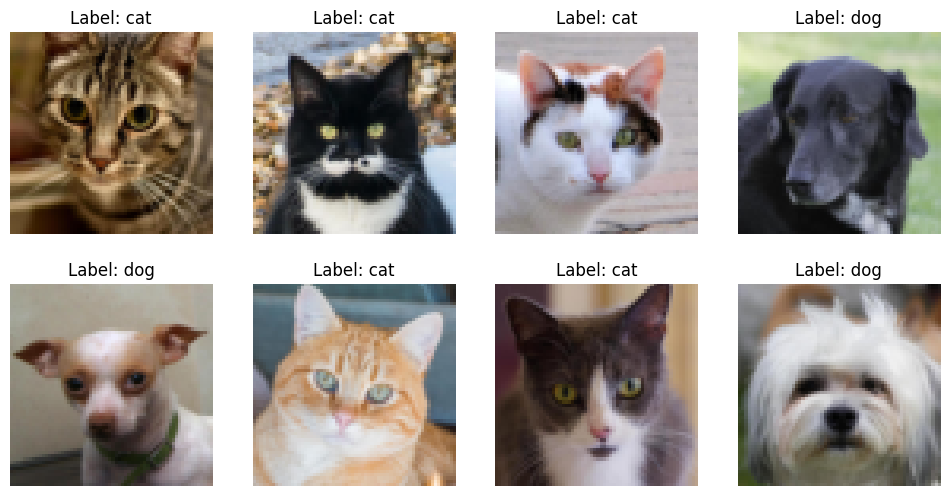

In [ ]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, train_classes = get_dataloaders("./afhq/train")

# Initialize Model (from previous code)
model = CVAE(latent_dim=128).to(device)

# 1. Peek at your database
show_batch(train_loader, train_classes)

# 2. (After training) Check transformations
# visualize_transformation(model, data_loader, device)

# Training util functions

In [5]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data, labels)
        
        # Calculate loss
        loss = loss_function(recon_batch, data, mu, logvar)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader.dataset)
    return avg_loss

def validate_epoch(model, dataloader, device):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            recon_batch, mu, logvar = model(data, labels)
            loss = loss_function(recon_batch, data, mu, logvar)
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader.dataset)
    return avg_loss

# Training Loop

In [11]:
train_loader, train_classes = get_dataloaders("./afhq/train")
val_loader, val_classes = get_dataloaders("./afhq/val",shuffle=False)

# --- Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 50
learning_rate = 1e-3

# Initialize Model and Optimizer
model = CVAE(latent_dim=128, num_classes=2, img_channels=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# --- Main Loop ---
for epoch in range(1, num_epochs + 1):
    # Call training function
    train_loss = train_epoch(model, train_loader, optimizer, device)
    
    # Call validation function
    val_loss = validate_epoch(model, val_loader, device)
    
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    
    # Optional: Save model checkpoint
    # torch.save(model.state_dict(), f"cvae_epoch_{epoch}.pth")

Epoch 1: Train Loss: 2664.6741 | Val Loss: 1854.5073
Epoch 2: Train Loss: 1492.7387 | Val Loss: 1431.4424
Epoch 3: Train Loss: 1229.7256 | Val Loss: 1267.4841
Epoch 4: Train Loss: 1106.3436 | Val Loss: 1173.2810
Epoch 5: Train Loss: 1005.8913 | Val Loss: 1087.5119
Epoch 6: Train Loss: 935.6522 | Val Loss: 1042.3605
Epoch 7: Train Loss: 890.0974 | Val Loss: 1011.2825
Epoch 8: Train Loss: 845.7825 | Val Loss: 970.5712
Epoch 9: Train Loss: 806.4232 | Val Loss: 920.9880
Epoch 10: Train Loss: 763.5822 | Val Loss: 906.3549
Epoch 11: Train Loss: 731.5939 | Val Loss: 865.4572
Epoch 12: Train Loss: 704.8577 | Val Loss: 871.3237
Epoch 13: Train Loss: 702.2694 | Val Loss: 870.3287
Epoch 14: Train Loss: 666.9012 | Val Loss: 838.7438
Epoch 15: Train Loss: 642.4758 | Val Loss: 825.1056
Epoch 16: Train Loss: 627.8457 | Val Loss: 859.8363
Epoch 17: Train Loss: 638.8744 | Val Loss: 807.0987
Epoch 18: Train Loss: 595.0796 | Val Loss: 792.9071
Epoch 19: Train Loss: 579.6418 | Val Loss: 788.1291
Epoch 20:

# Visualize trained model output

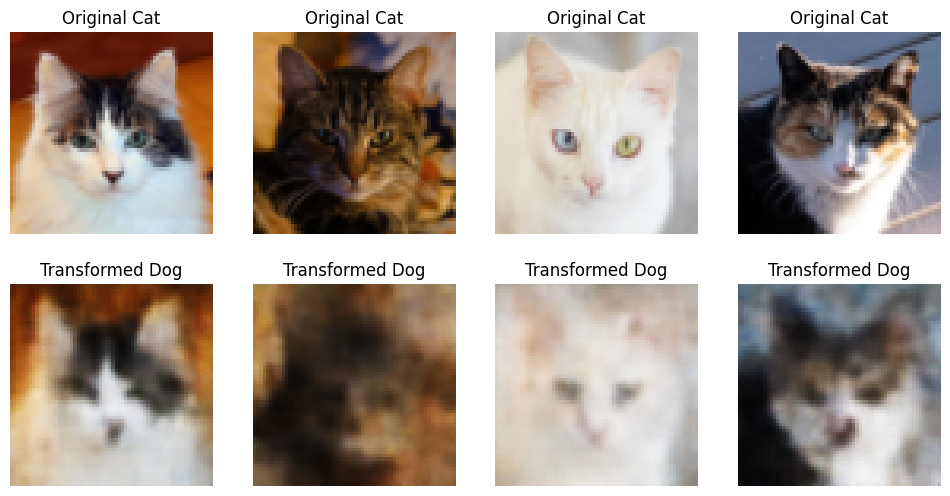

In [14]:
visualize_transformation(model, val_loader, device)